# OD Connectivity Analysis: School Accessibility and Commuting

This notebook evaluates the **demand-relevant connectivity** of the West Midlands
directed LTS network for two trip purposes central to the LTN 1/20 "cycling for
all" principle:

1. **School accessibility** (Part A): using OSM-derived school locations and LSOA
   centroids, we test how many children can reach their nearest school via a
   low-stress route, weighted by LSOA population.
2. **Commuting connectivity** (Part B): using Census 2011 MSOA-level OD commuting
   flows (preferred over 2021 data collected during COVID-19 lockdown), we test
   what proportion of short-distance commuting trips can be completed within each
   LTS-constrained network.

Both analyses employ **directed Dijkstra shortest-path routing** on LTS-filtered
subgraphs with 30 m gap bridging (consistent with notebook 05).

**Fast-path support.** On first run the gap-bridged subgraphs are cached to pickle.
Subsequent runs load the cache in seconds. Set `FORCE_RECOMPUTE = True` to rebuild.


In [96]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.spatial import cKDTree
from shapely.geometry import Point, LineString
from shapely import STRtree

DATA_DIR = Path('../Data/Raw')
CLEANED_DIR = Path('../Data/Cleaned')
OUTPUT_DIR = Path('../Data/Cleaned')
FIG_DIR = Path('../Figure')
FIG_DIR.mkdir(exist_ok=True)

CRS_BNG = 'EPSG:27700'
GAP_CLOSE_M = 30  # consistent with notebook 05

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

LTS_COLORS = {
    1: '#2ca02c',
    2: '#f0c929',
    3: '#e8601c',
    4: '#d62728',
}

STUDY_AREA_BOROUGHS = [
    'Birmingham', 'Coventry', 'Dudley', 'Sandwell',
    'Solihull', 'Walsall', 'Wolverhampton',
]

## 1. Data Loading

### 1.1 Study Area

In [2]:
raw_data = gpd.read_file(
    DATA_DIR / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_7781342770234899863/LAD_DEC_2025_UK_BFC.shp"
)
study_area = raw_data[raw_data['LAD25NM'].isin(STUDY_AREA_BOROUGHS)].copy()
study_area = study_area.to_crs(CRS_BNG)
study_area_union = study_area.unary_union

print(f"Study area: {len(STUDY_AREA_BOROUGHS)} boroughs, "
      f"{study_area.geometry.area.sum()/1e6:.1f} km²")

Study area: 7 boroughs, 901.7 km²


### 1.2 Directed LTS Network

In [3]:
edges = gpd.read_file(OUTPUT_DIR / "network_lts_with_junctions.gpkg")
edges = edges.to_crs(CRS_BNG)
edges['osid'] = edges['edge_id'].str.rsplit('_', n=1).str[0]

print(f"Directed edges: {len(edges):,}")
print(f"LTS distribution:")
print(edges['lts_final'].value_counts().sort_index())

Directed edges: 480,228
LTS distribution:
lts_final
1.0    227420
2.0    152180
3.0     46464
4.0     54164
Name: count, dtype: int64


### 1.3 Network Graph Construction and Gap Bridging

**Cache control.** Set `FORCE_RECOMPUTE = False` (default) to load pre-computed
gap-bridged subgraphs from pickle. Set to `True` to rebuild from the edges
GeoDataFrame. The cache stores `G_full`, `lts_subgraphs` (with gap bridges
already added in-place), and `node_coords`.

In [4]:
FORCE_RECOMPUTE = False

SUBGRAPH_PKL = OUTPUT_DIR / 'lts_subgraphs_gapbridged.pkl'
COORDS_PKL   = OUTPUT_DIR / 'node_coords.pkl'
GFULL_PKL    = OUTPUT_DIR / 'G_full.pkl'

In [5]:
# ----- Helper functions -----

def build_directed_graph(edges_gdf):
    """Build a directed NetworkX graph from the edges GeoDataFrame.
    
    Handles backward edges explicitly: since geometry is NOT reversed
    in Notebook 00's edge expansion, coords[0] is always the startnode
    and coords[-1] is always the endnode regardless of edge direction.
    """
    G = nx.DiGraph()
    node_coords = {}
    for _, row in edges_gdf.iterrows():
        u, v = row['from_node'], row['to_node']
        geom = row['geometry']
        G.add_edge(u, v,
                   length=row['geometry_length_m'],
                   lts=row['lts_final'],
                   facility_type=row['facility_type'],
                   edge_id=row['edge_id'],
                   osid=row['osid'])
        coords = list(geom.coords)
        # Backward edges share the same (unreversed) geometry,
        # so determine start/end from edge_dir, not from coord order.
        if row.get('edge_dir', 'forward') == 'forward':
            start_coord, end_coord = coords[0][:2], coords[-1][:2]
        else:
            start_coord, end_coord = coords[-1][:2], coords[0][:2]
        node_coords.setdefault(u, start_coord)
        node_coords.setdefault(v, end_coord)
    nx.set_node_attributes(G, {n: {'x': c[0], 'y': c[1]}
                               for n, c in node_coords.items()})
    return G, node_coords


def extract_lts_subgraph(G, max_lts):
    """Extract a directed subgraph containing only edges with lts <= max_lts."""
    edge_list = [(u, v, d) for u, v, d in G.edges(data=True)
                 if d['lts'] <= max_lts]
    H = nx.DiGraph()
    H.add_edges_from(edge_list)
    for n in H.nodes():
        if n in G.nodes:
            H.nodes[n].update(G.nodes[n])
    return H


def close_gaps_directed(G, node_coords, max_gap_m, lts_level):
    """Bridge gaps <= max_gap_m between different weakly connected components.
    
    Adds bidirectional edges with facility_type='gap_bridge' and
    lts=lts_level. Only bridges across different components.
    """
    nodes_in_graph = [n for n in G.nodes() if n in node_coords]
    if len(nodes_in_graph) < 2:
        return 0
    node_list = list(nodes_in_graph)
    coords_array = np.array([node_coords[n] for n in node_list])
    tree = cKDTree(coords_array)
    pairs = tree.query_pairs(r=max_gap_m)

    comp_map = {}
    for comp_id, comp in enumerate(nx.weakly_connected_components(G)):
        for n in comp:
            comp_map[n] = comp_id

    gaps_closed = 0
    for i, j in pairs:
        u, v = node_list[i], node_list[j]
        if comp_map.get(u) == comp_map.get(v):
            continue
        if G.has_edge(u, v) and G.has_edge(v, u):
            continue
        dist = np.linalg.norm(coords_array[i] - coords_array[j])
        if not G.has_edge(u, v):
            G.add_edge(u, v, length=dist, lts=lts_level,
                       facility_type='gap_bridge',
                       edge_id=f'gap_{u}_{v}', osid=f'gap_{u}_{v}')
        if not G.has_edge(v, u):
            G.add_edge(v, u, length=dist, lts=lts_level,
                       facility_type='gap_bridge',
                       edge_id=f'gap_{v}_{u}', osid=f'gap_{u}_{v}')
        gaps_closed += 1
        old_comp, new_comp = comp_map[v], comp_map[u]
        for n in list(comp_map.keys()):
            if comp_map[n] == old_comp:
                comp_map[n] = new_comp
    return gaps_closed

In [6]:
import pickle

if not FORCE_RECOMPUTE and SUBGRAPH_PKL.exists():
    # ===== FAST PATH: load cached gap-bridged subgraphs =====
    print("Loading cached gap-bridged subgraphs...")
    with open(SUBGRAPH_PKL, 'rb') as f:
        lts_subgraphs = pickle.load(f)
    with open(COORDS_PKL, 'rb') as f:
        node_coords = pickle.load(f)

    # G_full may not exist if cached by the old notebook
    if GFULL_PKL.exists():
        with open(GFULL_PKL, 'rb') as f:
            G_full = pickle.load(f)
        print("  G_full loaded from cache.")
    else:
        print("  G_full.pkl not found — rebuilding from edges (one-time)...")
        G_full, node_coords = build_directed_graph(edges)
        with open(GFULL_PKL, 'wb') as f:
            pickle.dump(G_full, f)
        print("  G_full saved to cache.")

    for lts in [1, 2, 3, 4]:
        H = lts_subgraphs[lts]
        n_gaps = sum(1 for _, _, d in H.edges(data=True)
                     if d.get('facility_type') == 'gap_bridge')
        total_km = sum(d['length'] for _, _, d in H.edges(data=True)) / 1000
        print(f"  LTS <= {lts}: {H.number_of_nodes():>7,} nodes, "
              f"{H.number_of_edges():>7,} edges, {total_km:>8,.1f} km "
              f"({n_gaps:,} gap bridges)")
    print(f"  G_full: {G_full.number_of_nodes():,} nodes, "
          f"{G_full.number_of_edges():,} edges")
    print("Done.")

else:
    # ===== SLOW PATH: build everything from scratch =====
    print("Building directed graph from edges GeoDataFrame...")
    G_full, node_coords = build_directed_graph(edges)
    print(f"G_full: {G_full.number_of_nodes():,} nodes, "
          f"{G_full.number_of_edges():,} edges")

    lts_subgraphs = {}
    for lts_level in [1, 2, 3, 4]:
        H = extract_lts_subgraph(G_full, lts_level)
        lts_subgraphs[lts_level] = H
        total_km = sum(d['length'] for _, _, d in H.edges(data=True)) / 1000
        print(f"  LTS <= {lts_level}: {H.number_of_nodes():>7,} nodes, "
              f"{H.number_of_edges():>7,} edges, {total_km:>8,.1f} km")

    print(f"\nGap closing (max {GAP_CLOSE_M} m):")
    print("-" * 65)
    for lts_level in [1, 2, 3, 4]:
        H = lts_subgraphs[lts_level]
        n_before = nx.number_weakly_connected_components(H)
        n_gaps = close_gaps_directed(H, node_coords, GAP_CLOSE_M, lts_level)
        n_after = nx.number_weakly_connected_components(H)
        print(f"  LTS <= {lts_level}: {n_gaps:>5,} gaps closed | "
              f"Components: {n_before:>6,} -> {n_after:>6,} "
              f"({n_before - n_after:>5,} merged)")

    with open(SUBGRAPH_PKL, 'wb') as f:
        pickle.dump(lts_subgraphs, f)
    with open(COORDS_PKL, 'wb') as f:
        pickle.dump(node_coords, f)
    with open(GFULL_PKL, 'wb') as f:
        pickle.dump(G_full, f)
    print("\nSaved to cache.")

Loading cached gap-bridged subgraphs...
  G_full loaded from cache.
  LTS <= 1: 191,802 nodes, 290,801 edges, 11,037.1 km (63,892 gap bridges)
  LTS <= 2: 222,327 nodes, 430,932 edges, 18,824.7 km (53,712 gap bridges)
  LTS <= 3: 239,161 nodes, 474,100 edges, 20,981.5 km (49,886 gap bridges)
  LTS <= 4: 253,548 nodes, 521,792 edges, 23,818.9 km (43,362 gap bridges)
  G_full: 253,548 nodes, 478,430 edges
Done.


### 1.4 Largest Weakly Connected Component and Node Snapping

In [7]:
components = sorted(nx.weakly_connected_components(G_full), key=len, reverse=True)
giant = components[0]

print(f"Total weakly connected components: {len(components)}")
print(f"LWCC: {len(giant):,} nodes ({len(giant)/G_full.number_of_nodes()*100:.1f}%)")

# Node lookup restricted to LWCC
nodes_data = []
for n in giant:
    if n in node_coords:
        nodes_data.append({'node_id': n, 'x': node_coords[n][0], 'y': node_coords[n][1]})
nodes_giant = pd.DataFrame(nodes_data)
nodes_giant_gdf = gpd.GeoDataFrame(
    nodes_giant, geometry=gpd.points_from_xy(nodes_giant.x, nodes_giant.y), crs=CRS_BNG
)
tree_giant = STRtree(nodes_giant_gdf.geometry.values)

def snap_to_giant(centroid):
    idx = tree_giant.nearest(centroid)
    return nodes_giant_gdf.iloc[idx]["node_id"]

print(f"Nodes available for snapping: {len(nodes_giant_gdf):,}")

Total weakly connected components: 21944
LWCC: 193,995 nodes (76.5%)
Nodes available for snapping: 193,995


### 1.5 Sparse Graph Construction

Build sparse adjacency matrices for `scipy.sparse.csgraph.dijkstra`. Gap bridge
edges are deduplicated: if the same `(u, v)` pair is bridged in multiple LTS
subgraphs, only the bridge with the lowest LTS value is kept (it will be included
in all higher-threshold graphs automatically).

In [10]:
# Node index mapping: all nodes from edges + gap bridge nodes
all_node_ids = set(edges['from_node']) | set(edges['to_node'])

for lts_level in [1, 2, 3, 4]:
    for u, v, d in lts_subgraphs[lts_level].edges(data=True):
        if d.get('facility_type') == 'gap_bridge':
            all_node_ids.update([u, v])

all_node_ids = list(all_node_ids)
node_to_idx = {nid: i for i, nid in enumerate(all_node_ids)}
n_nodes = len(node_to_idx)

# Base edges from GeoDataFrame
all_src = edges['from_node'].map(node_to_idx).values.tolist()
all_dst = edges['to_node'].map(node_to_idx).values.tolist()
all_len = edges['geometry_length_m'].values.astype(float).tolist()
all_lts = edges['lts_final'].values.tolist()

# Gap bridges: deduplicate — keep lowest LTS per (u, v)
gap_edges = {}  # (u_idx, v_idx) -> (length, lts)
for lts_level in [1, 2, 3, 4]:
    for u, v, d in lts_subgraphs[lts_level].edges(data=True):
        if d.get('facility_type') == 'gap_bridge':
            key = (node_to_idx[u], node_to_idx[v])
            if key not in gap_edges or d['lts'] < gap_edges[key][1]:
                gap_edges[key] = (d['length'], d['lts'])

for (ui, vi), (length, lts) in gap_edges.items():
    all_src.append(ui)
    all_dst.append(vi)
    all_len.append(length)
    all_lts.append(lts)

all_src = np.array(all_src)
all_dst = np.array(all_dst)
all_len = np.array(all_len, dtype=float)
all_lts = np.array(all_lts)


def build_strict_graph(lts_threshold):
    mask = all_lts <= lts_threshold
    return csr_matrix(
        (all_len[mask], (all_src[mask], all_dst[mask])),
        shape=(n_nodes, n_nodes)
    )


print(f"Node index size: {n_nodes:,}")
print(f"Base edges: {len(edges):,}")
print(f"Gap bridges (deduplicated): {len(gap_edges):,}")
print(f"Total edges in sparse arrays: {len(all_src):,}")

Node index size: 253,548
Base edges: 480,228
Gap bridges (deduplicated): 146,732
Total edges in sparse arrays: 626,960


## Part A -- School Accessibility

### 2. Data Preparation

#### 2.1 LSOA Boundaries and Population

In [12]:
lsoa_uk = gpd.read_file(
    DATA_DIR / "Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5_-3761339731474027792.geojson"
)
lsoa_uk = lsoa_uk.to_crs(CRS_BNG)

lsoa_uk['centroid'] = lsoa_uk.geometry.centroid
lsoa_uk_centroids = lsoa_uk.set_geometry('centroid')
lsoa_wm = gpd.sjoin(lsoa_uk_centroids, study_area[["LAD25NM", "geometry"]], predicate="within")
lsoa_wm = lsoa_wm.set_geometry("geometry").drop(columns=["centroid", "index_right"])

# Join LSOA population (Census 2021 TS001)
lsoa_pop = pd.read_csv(DATA_DIR / 'census2021-ts001/census2021-ts001-lsoa.csv')
lsoa_pop = lsoa_pop.rename(columns={
    'geography code': 'LSOA21CD',
    'Residence type: Total; measures: Value': 'population'
})
lsoa_wm = lsoa_wm.merge(lsoa_pop[['LSOA21CD', 'population']], on='LSOA21CD', how='left')

# Snap LSOA centroids to LWCC
lsoa_wm_cents = lsoa_wm.copy().set_geometry(lsoa_wm.geometry.centroid)
lsoa_wm_cents["snapped_node"] = lsoa_wm_cents.geometry.apply(snap_to_giant)
lsoa_to_node = dict(zip(lsoa_wm_cents["LSOA21CD"], lsoa_wm_cents["snapped_node"]))

print(f"WM LSOAs: {len(lsoa_wm):,}")
print(f"Total population: {lsoa_wm['population'].sum():,.0f}")
print(f"Snapped to LWCC: {len(lsoa_to_node):,}")

WM LSOAs: 1,718
Total population: 2,917,976
Snapped to LWCC: 1,718


#### 2.2 School Locations

In [13]:
import pyrosm

pbf_path = DATA_DIR / "west-midlands-260504.osm.pbf"
osm = pyrosm.OSM(str(pbf_path))
pois = osm.get_pois(custom_filter={"amenity": ["school"]})
pois = pois.to_crs(CRS_BNG)
pois["geometry"] = pois.geometry.centroid

schools_wm = gpd.sjoin(pois, study_area[["LAD25NM", "geometry"]], predicate="within")
schools_wm = schools_wm.drop(columns=["index_right"]).reset_index(drop=True)

print(f"Schools in West Midlands: {len(schools_wm)}")
print(f"By borough:")
print(schools_wm.groupby("LAD25NM").size().sort_values(ascending=False))

# Snap schools to LWCC
schools_wm["snapped_node"] = schools_wm.geometry.apply(snap_to_giant)
school_node_indices = np.array([
    node_to_idx[n] for n in schools_wm["snapped_node"].unique()
    if n in node_to_idx
])
print(f"\nSchool nodes (unique, in LWCC): {len(school_node_indices)}")

Schools in West Midlands: 1220
By borough:
LAD25NM
Birmingham       484
Sandwell         149
Coventry         139
Walsall          128
Dudley           121
Wolverhampton    110
Solihull          89
dtype: int64

School nodes (unique, in LWCC): 1199


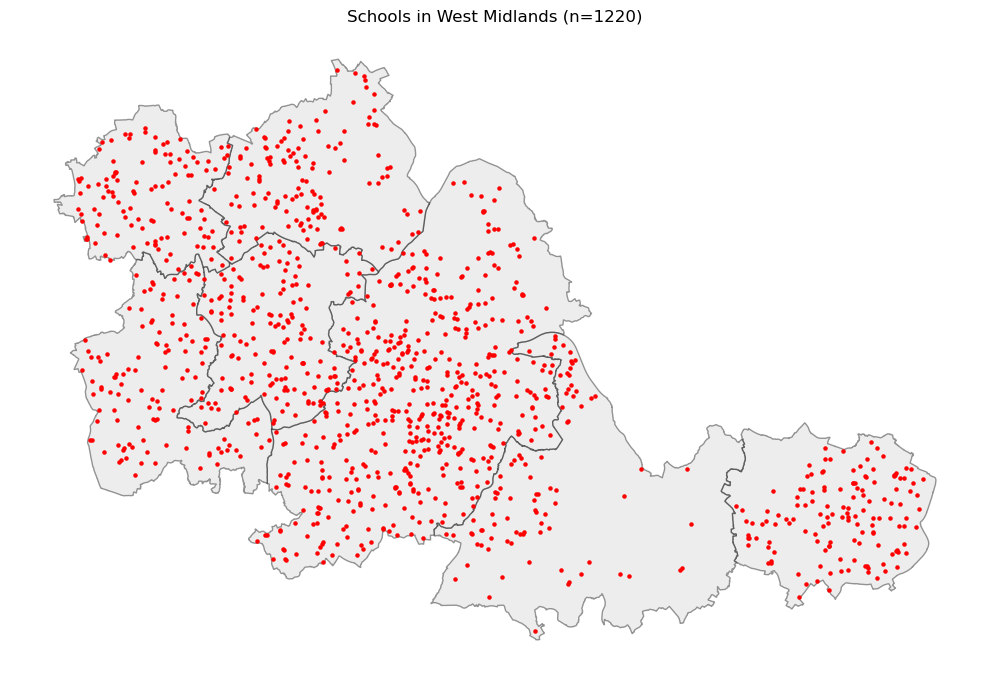

In [14]:
# Map of schools
fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, facecolor="lightgrey", edgecolor="black", alpha=0.4)
schools_wm.plot(ax=ax, color="red", markersize=5, zorder=3)
ax.set_title(f"Schools in West Midlands (n={len(schools_wm)})")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG_DIR / "schools_map.png", dpi=200, bbox_inches="tight")
plt.show()

### 3. School Accessibility Computation

School accessibility uses **reversed-graph Dijkstra** -- routing from each school
node outward on the transposed adjacency matrix gives the shortest distance *to*
that school from every node. For each LSOA, the minimum across all schools gives
the nearest-school distance.

Routing scenarios
- **Strict** LTS <= 1, 2, 3, 4
- **Tolerance** Route on LTS <= (target + 1), accept if distance <= (1 + tol)
  x unconstrained distance. Tolerances: 5%, 10%.

In [16]:
def compute_school_accessibility(graph, school_indices, lsoa_to_node, node_to_idx):
    graph_T = graph.T.tocsr()
    dist_matrix = dijkstra(graph_T, directed=True, indices=school_indices)
    results = {}
    for lsoa_code, node_id in lsoa_to_node.items():
        if node_id not in node_to_idx:
            continue
        node_idx = node_to_idx[node_id]
        min_dist = dist_matrix[:, node_idx].min()
        results[lsoa_code] = min_dist if np.isfinite(min_dist) else np.nan
    return results

# Strict LTS routing
school_results = {}
for lts in [1, 2, 3, 4]:
    print(f"Computing school accessibility: LTS ≤ {lts}...")
    graph = build_strict_graph(lts)
    dists = compute_school_accessibility(graph, school_node_indices, lsoa_to_node, node_to_idx)
    school_results[lts] = dists
    reachable = sum(1 for d in dists.values() if np.isfinite(d))
    print(f"  Reachable: {reachable}/{len(dists)} ({reachable/len(dists)*100:.1f}%)")

# Unconstrained baseline (= LTS ≤ 4)
baseline_school = school_results[4]

Computing school accessibility: LTS ≤ 1...
  Reachable: 72/1718 (4.2%)
Computing school accessibility: LTS ≤ 2...
  Reachable: 1122/1718 (65.3%)
Computing school accessibility: LTS ≤ 3...
  Reachable: 1468/1718 (85.4%)
Computing school accessibility: LTS ≤ 4...
  Reachable: 1717/1718 (99.9%)


### 4. School Accessibility Results

#### 4.1 Summary Table (Population-Weighted)

In [17]:
# Population-weighted school accessibility summary (strict only)
lsoa_pop_dict = dict(zip(lsoa_wm['LSOA21CD'], lsoa_wm['population']))
total_pop = sum(lsoa_pop_dict.get(l, 0) for l in lsoa_to_node.keys())

print("=" * 85)
print("School Accessibility Summary (nearest school, directed routing)")
print("=" * 85)
print(f"{'Scenario':<20}  {'LSOAs':>7}  {'% LSOAs':>8}  {'Pop':>10}  {'% Pop':>7}")
print("-" * 85)

n_lsoas = len(lsoa_to_node)

for lts in [1, 2, 3, 4]:
    dists = school_results[lts]
    reachable_lsoas = [l for l, d in dists.items() if np.isfinite(d)]
    n_reach = len(reachable_lsoas)
    pop_reach = sum(lsoa_pop_dict.get(l, 0) for l in reachable_lsoas)
    label = f"LTS ≤ {lts}"
    print(f"{label:<20}  {n_reach:>7,}  {n_reach/n_lsoas*100:>7.1f}%  "
          f"{pop_reach:>10,}  {pop_reach/total_pop*100:>6.1f}%")


School Accessibility Summary (nearest school, directed routing)
Scenario                LSOAs   % LSOAs         Pop    % Pop
-------------------------------------------------------------------------------------
LTS ≤ 1                    72      4.2%     119,256     4.1%
LTS ≤ 2                 1,122     65.3%   1,907,527    65.4%
LTS ≤ 3                 1,468     85.4%   2,492,880    85.4%
LTS ≤ 4                 1,717     99.9%   2,915,106    99.9%


#### 4.2 Cumulative Accessibility Curves (Strict)

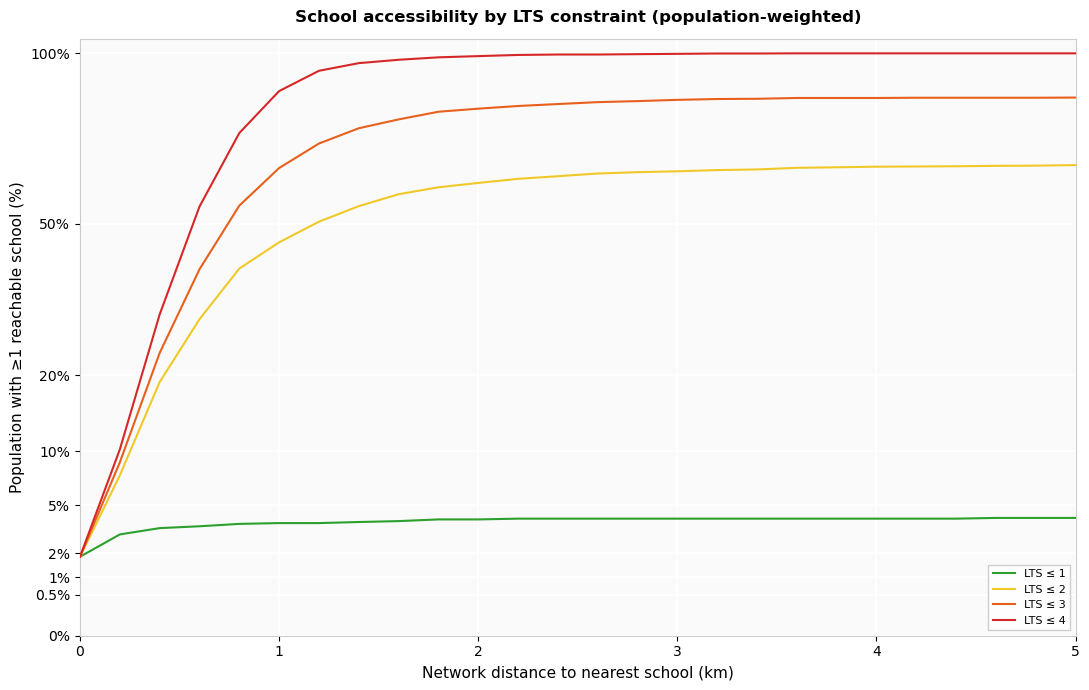

In [18]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#fafafa")
ax.grid(True, color="white", linewidth=1.2, zorder=0)
ax.set_axisbelow(True)

thresholds_m = np.arange(0, 10001, 200)

for lts in [1, 2, 3, 4]:
    dists = school_results[lts]
    dist_values = np.array([dists.get(lsoa, np.nan) for lsoa in lsoa_to_node.keys()])
    pop_values = np.array([lsoa_pop_dict.get(lsoa, 0) for lsoa in lsoa_to_node.keys()])

    # Population-weighted cumulative curve
    cum_pct = []
    for d in thresholds_m:
        mask = dist_values <= d
        cum_pct.append(np.where(np.isnan(dist_values), 0, mask).dot(pop_values) / total_pop * 100)
    ax.plot(thresholds_m / 1000, cum_pct,
            color=LTS_COLORS[lts], linewidth=1.5, label=f"LTS ≤ {lts}", zorder=3)

ax.set_yscale("function",
              functions=(lambda x: np.sqrt(x), lambda x: x**2))
ax.set_ylim(0, 105)
ax.set_xlim(0, 5)
ax.set_yticks([0, 0.5, 1, 2, 5, 10, 20, 50, 100])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:g}%"))
ax.set_xlabel("Network distance to nearest school (km)", fontsize=11)
ax.set_ylabel("Population with ≥1 reachable school (%)", fontsize=11)
ax.set_title("School accessibility by LTS constraint (population-weighted)",
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc="lower right", fontsize=8, frameon=True,
          fancybox=False, edgecolor="#cccccc", framealpha=0.95)
for spine in ax.spines.values():
    spine.set_color("#cccccc")
plt.tight_layout()
plt.savefig(FIG_DIR / "school_accessibility_by_lts_popweighted.png", dpi=300, bbox_inches="tight")
plt.show()

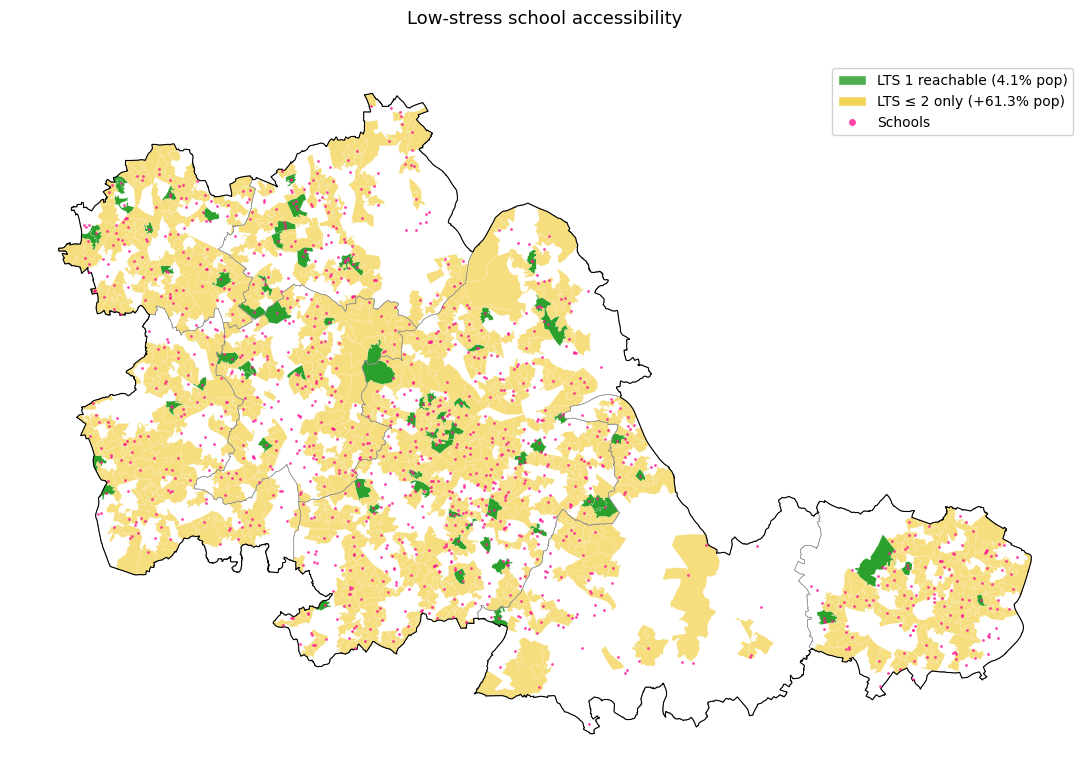

In [58]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np

# ---------------------------------------------------------------
# 1. Three-tier accessibility class per LSOA (mutually exclusive)
#    Priority: LTS1 reachable > LTS2-only > unreachable
# ---------------------------------------------------------------
def school_tier(lsoa):
    d1 = school_results[1].get(lsoa, np.nan)
    d2 = school_results[2].get(lsoa, np.nan)
    if np.isfinite(d1):
        return "lts1"
    elif np.isfinite(d2):
        return "lts2"
    else:
        return "none"

lsoa_wm = lsoa_wm.copy()
lsoa_wm["school_tier"] = lsoa_wm["LSOA21CD"].map(school_tier)

# ---------------------------------------------------------------
# 2. Population-weighted shares (cumulative)
# ---------------------------------------------------------------
def pop_share(tier_set):
    codes = lsoa_wm.loc[lsoa_wm["school_tier"].isin(tier_set), "LSOA21CD"]
    return sum(lsoa_pop_dict.get(c, 0) for c in codes) / total_pop * 100

pct_lts1 = pop_share(["lts1"])
pct_lts2 = pop_share(["lts1", "lts2"])

# ---------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------
tier_colors = {"lts1": "#2ca02c", "lts2": "#f0c82998"}   # unreachable dropped

fig, ax = plt.subplots(figsize=(11, 11))

# Base fill by accessibility tier (only reachable tiers plotted)
for tier, color in tier_colors.items():
    subset = lsoa_wm[lsoa_wm["school_tier"] == tier]
    if len(subset):
        subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.1)

# LAD boundaries inside the study area (thin grey internal lines)
study_area.boundary.plot(ax=ax, color="#888888", linewidth=0.4, zorder=3)

# Study-area outer boundary (thicker black outline)
study_area.dissolve().boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=4)

# School locations (align CRS just in case)
schools_plot = schools_wm.to_crs(lsoa_wm.crs)
ax.scatter(
    schools_plot.geometry.x, schools_plot.geometry.y,
    s=4, color="#FF1493", alpha=0.8, marker="o",
    linewidths=0, zorder=5,
)

# ---- Legend ----
legend_elems = [
    Patch(facecolor="#2ca02cd5", edgecolor="white",
          label=f"LTS 1 reachable ({pct_lts1:.1f}% pop)"),
    Patch(facecolor="#f0c829ca", edgecolor="white",
          label=f"LTS \u2264 2 only (+{pct_lts2 - pct_lts1:.1f}% pop)"),
    Line2D([0], [0], marker="o", color="none", markeredgewidth=0, markerfacecolor="#FF1493",
           markersize=5, alpha=0.8, label="Schools"),
]
ax.legend(handles=legend_elems, loc="upper right", fontsize=10,
          frameon=True, framealpha=0.9)

ax.set_title(
    f"Low-stress school accessibility\n",
    fontsize=13, pad=12,
)
ax.set_axis_off()
plt.tight_layout()
# plt.savefig(FIG_DIR / "school_accessibility_tiers.png", dpi=300, bbox_inches="tight")
plt.show()

## Part B -- Commuting Connectivity

### 5. Census 2011 OD Data

In [21]:
# Load MSOA boundaries
msoa = gpd.read_file(
    DATA_DIR / "Middle_Layer_Super_Output_Areas_Dec_2001_Boundaries_EW_BGC_2022_1570857564621828750.geojson"
)
msoa = msoa.to_crs(CRS_BNG)
msoa["centroid"] = msoa.geometry.centroid
msoa_centroids = msoa.set_geometry("centroid")
msoa_wm = gpd.sjoin(msoa_centroids, study_area[["LAD25NM", "geometry"]], predicate="within")
msoa_wm = msoa_wm.set_geometry("geometry").drop(columns=["centroid", "index_right"])

msoa_code_col = "MSOA21CD" if "MSOA21CD" in msoa_wm.columns else "MSOA01CD"
print(f"WM MSOAs: {len(msoa_wm)}")

WM MSOAs: 356


In [22]:
# Load and filter Census 2011 OD data
census_2011 = pd.read_csv(DATA_DIR / "census_2011/ODWP03EW_MSOA.csv")
print(f"Raw data: {len(census_2011):,} rows")

census_2011["MSOA of workplace code"] = census_2011["MSOA of workplace code"].astype(str).str.strip()
census_2011["Middle layer Super Output Areas code"] = census_2011["Middle layer Super Output Areas code"].astype(str).str.strip()

census_2011 = census_2011[~census_2011["MSOA of workplace code"].isin({"-8", "999999999"})].copy()
census_2011["Place of work indicator (4 categories) code"] = pd.to_numeric(
    census_2011["Place of work indicator (4 categories) code"], errors="coerce"
)
census_2011 = census_2011[census_2011["Place of work indicator (4 categories) code"] == 3].copy()
print(f"After filtering to commuters (code=3): {len(census_2011):,} rows")

census_2011["Count"] = pd.to_numeric(census_2011["Count"], errors="coerce").fillna(0).astype(int)
od = (
    census_2011.groupby(
        ["Middle layer Super Output Areas code", "Middle layer Super Output Areas label",
         "MSOA of workplace code", "MSOA of workplace label"],
        as_index=False,
    )["Count"].sum()
)
od.columns = ["o_msoa", "o_name", "d_msoa", "d_name", "flow"]
print(f"After aggregation: {len(od):,} OD pairs, total flow = {od['flow'].sum():,}")

# Filter to WM internal trips
wm_msoas = set(msoa_wm[msoa_code_col])
od_wm = od[od["o_msoa"].isin(wm_msoas) & od["d_msoa"].isin(wm_msoas)].copy()
od_wm = od_wm[od_wm["flow"] > 0]
print(f"\nWM internal OD pairs: {len(od_wm):,}, total flow = {od_wm['flow'].sum():,}")

# Exclude intra-MSOA trips
intra = od_wm[od_wm["o_msoa"] == od_wm["d_msoa"]]
print(f"Intra-MSOA pairs: {len(intra):,} ({intra['flow'].sum()/od_wm['flow'].sum()*100:.1f}% of flow)")
od_wm = od_wm[od_wm["o_msoa"] != od_wm["d_msoa"]].copy()
total_inter_flow = od_wm["flow"].sum()
print(f"Inter-MSOA OD pairs: {len(od_wm):,}, flow = {total_inter_flow:,}")

# Filter to ≤ 8 km straight-line distance
msoa_cent_dict = dict(zip(msoa_wm[msoa_code_col], msoa_wm.geometry.centroid))
od_wm["sl_dist_m"] = od_wm.apply(
    lambda r: msoa_cent_dict[r["o_msoa"]].distance(msoa_cent_dict[r["d_msoa"]])
    if r["o_msoa"] in msoa_cent_dict and r["d_msoa"] in msoa_cent_dict else np.nan,
    axis=1
)
od_wm_8km = od_wm[od_wm["sl_dist_m"] <= 8000].copy()
total_8km_flow = od_wm_8km["flow"].sum()
print(f"\nOD pairs ≤ 8 km: {len(od_wm_8km):,}, flow = {total_8km_flow:,} "
      f"({total_8km_flow/total_inter_flow*100:.1f}% of inter-MSOA flow)")

Raw data: 2,587,993 rows
After filtering to commuters (code=3): 2,538,509 rows
After aggregation: 1,829,955 OD pairs, total flow = 15,094,155

WM internal OD pairs: 56,664, total flow = 540,011
Intra-MSOA pairs: 340 (6.2% of flow)
Inter-MSOA OD pairs: 56,324, flow = 506,372

OD pairs ≤ 8 km: 19,770, flow = 370,221 (73.1% of inter-MSOA flow)


### 5.1 Snap MSOA Centroids to Network

In [23]:
msoa_codes = set(od_wm_8km["o_msoa"]) | set(od_wm_8km["d_msoa"])
msoa_cents = msoa_wm[msoa_wm[msoa_code_col].isin(msoa_codes)].copy()
msoa_cents = msoa_cents.set_geometry(msoa_cents.geometry.centroid)
msoa_cents["snapped_node"] = msoa_cents.geometry.apply(snap_to_giant)
msoa_to_node = dict(zip(msoa_cents[msoa_code_col], msoa_cents["snapped_node"]))

print(f"Snapped {len(msoa_to_node)} MSOA centroids to LWCC nodes")

Snapped 340 MSOA centroids to LWCC nodes


### 6. Commuting OD Routing

In [24]:
def compute_od_distances(graph, msoa_to_node, node_to_idx, od_df):
    origin_msoas = od_df["o_msoa"].unique()
    origin_nodes = [msoa_to_node[m] for m in origin_msoas if m in msoa_to_node]
    origin_indices = np.array([node_to_idx[n] for n in origin_nodes if n in node_to_idx])

    dist_matrix = dijkstra(graph, directed=True, indices=origin_indices)

    origin_to_row = {}
    row_idx = 0
    for m in origin_msoas:
        if m in msoa_to_node and msoa_to_node[m] in node_to_idx:
            origin_to_row[m] = row_idx
            row_idx += 1

    result = od_df.copy()
    o_rows = result["o_msoa"].map(origin_to_row)
    d_cols = result["d_msoa"].map(msoa_to_node).map(node_to_idx)

    distances = np.full(len(result), np.nan)
    valid = o_rows.notna() & d_cols.notna()
    if valid.any():
        r = o_rows[valid].astype(int).values
        c = d_cols[valid].astype(int).values
        d = dist_matrix[r, c]
        d[d == np.inf] = np.nan
        distances[valid.values] = d
    result["distance_m"] = distances
    return result

In [25]:
commute_results = {}

# Unconstrained baseline
print("Computing unconstrained baseline (LTS ≤ 4)...")
graph_unc = build_strict_graph(4)
res_unc = compute_od_distances(graph_unc, msoa_to_node, node_to_idx, od_wm_8km)
commute_results["unconstrained"] = res_unc
conn = res_unc["distance_m"].notna().sum()
print(f"  Connected: {conn:,} / {len(res_unc):,} ({conn/len(res_unc)*100:.1f}%)")

# Strict routing: LTS ≤ 1, 2, 3
for lts in [1, 2, 3]:
    print(f"\nComputing strict LTS ≤ {lts}...")
    graph = build_strict_graph(lts)
    res = compute_od_distances(graph, msoa_to_node, node_to_idx, od_wm_8km)
    commute_results[(lts, "strict")] = res
    conn = res["distance_m"].notna().sum()
    print(f"  Connected: {conn:,} / {len(res):,} ({conn/len(res)*100:.1f}%)")

Computing unconstrained baseline (LTS ≤ 4)...
  Connected: 19,770 / 19,770 (100.0%)

Computing strict LTS ≤ 1...
  Connected: 1 / 19,770 (0.0%)

Computing strict LTS ≤ 2...
  Connected: 2,212 / 19,770 (11.2%)

Computing strict LTS ≤ 3...
  Connected: 10,465 / 19,770 (52.9%)


### 7. Commuting Connectivity Results

#### 7.1 Summary Statistics

In [26]:
print("=" * 85)
print("Commuting OD Connectivity Summary (≤ 8 km straight-line)")
print("=" * 85)
print(f"Total OD pairs (≤ 8 km): {len(od_wm_8km):,}")
print(f"Total flow (≤ 8 km):     {total_8km_flow:,}")
print()
print(f"{'Scenario':<25}  {'Pairs':>8}  {'% Pairs':>8}  {'Flow':>10}  {'% Flow':>8}")
print("-" * 85)

# Unconstrained
unc = commute_results["unconstrained"]
unc_conn = unc.dropna(subset=["distance_m"])
print(f"{'Unconstrained (LTS ≤ 4)':<25}  {len(unc_conn):>8,}  "
      f"{len(unc_conn)/len(od_wm_8km)*100:>7.1f}%  "
      f"{unc_conn['flow'].sum():>10,}  "
      f"{unc_conn['flow'].sum()/total_8km_flow*100:>7.1f}%")

# Strict scenarios only
for lts in [1, 2, 3]:
    strict = commute_results[(lts, "strict")]
    s_conn = strict.dropna(subset=["distance_m"])
    label = f"LTS ≤ {lts}"
    print(f"{label:<25}  {len(s_conn):>8,}  "
          f"{len(s_conn)/len(od_wm_8km)*100:>7.1f}%  "
          f"{s_conn['flow'].sum():>10,}  "
          f"{s_conn['flow'].sum()/total_8km_flow*100:>7.1f}%")


Commuting OD Connectivity Summary (≤ 8 km straight-line)
Total OD pairs (≤ 8 km): 19,770
Total flow (≤ 8 km):     370,221

Scenario                      Pairs   % Pairs        Flow    % Flow
-------------------------------------------------------------------------------------
Unconstrained (LTS ≤ 4)      19,770    100.0%     370,221    100.0%
LTS ≤ 1                           1      0.0%          21      0.0%
LTS ≤ 2                       2,212     11.2%      48,255     13.0%
LTS ≤ 3                      10,465     52.9%     188,139     50.8%


In [27]:
# Detour analysis for connected pairs (flow-weighted)
def weighted_quantile(values, quantile, weights):
    sorter = np.argsort(values)
    v = np.array(values)[sorter]
    w = np.array(weights)[sorter]
    cum = np.cumsum(w) - 0.5 * w
    cum /= w.sum()
    return np.interp(quantile, cum, v)

unc = commute_results["unconstrained"]
base = unc.set_index(["o_msoa", "d_msoa"])["distance_m"]
flow_ix = od_wm_8km.set_index(["o_msoa", "d_msoa"])["flow"]

for lts in [1, 2, 3]:
    strict = commute_results[(lts, "strict")].set_index(["o_msoa", "d_msoa"])["distance_m"]
    aligned = pd.DataFrame({"base": base, "strict": strict, "flow": flow_ix}).dropna()
    if len(aligned) == 0:
        print(f"\nLTS ≤ {lts} strict — no connected pairs")
        continue
    aligned["ratio"] = aligned["strict"] / aligned["base"]
    w = aligned["flow"].values
    r = aligned["ratio"].values

    print(f"\nLTS ≤ {lts} strict — detour ratio (flow-weighted, connected pairs only):")
    print(f"  Connected pairs: {len(aligned):,}")
    print(f"  Connected flow:  {aligned['flow'].sum():,.0f} "
          f"({aligned['flow'].sum()/total_8km_flow*100:.1f}% of ≤8 km flow)")
    print(f"  Median:          {weighted_quantile(r, 0.5, w):.2f}x")
    print(f"  Mean:            {np.average(r, weights=w):.2f}x")
    print(f"  90th pct:        {weighted_quantile(r, 0.9, w):.2f}x")



LTS ≤ 1 strict — detour ratio (flow-weighted, connected pairs only):
  Connected pairs: 1
  Connected flow:  21 (0.0% of ≤8 km flow)
  Median:          1.22x
  Mean:            1.22x
  90th pct:        1.22x

LTS ≤ 2 strict — detour ratio (flow-weighted, connected pairs only):
  Connected pairs: 2,212
  Connected flow:  48,255 (13.0% of ≤8 km flow)
  Median:          1.73x
  Mean:            2.42x
  90th pct:        4.23x

LTS ≤ 3 strict — detour ratio (flow-weighted, connected pairs only):
  Connected pairs: 10,465
  Connected flow:  188,139 (50.8% of ≤8 km flow)
  Median:          1.46x
  Mean:            1.75x
  90th pct:        2.71x


#### 7.2 Cumulative Flow Curves

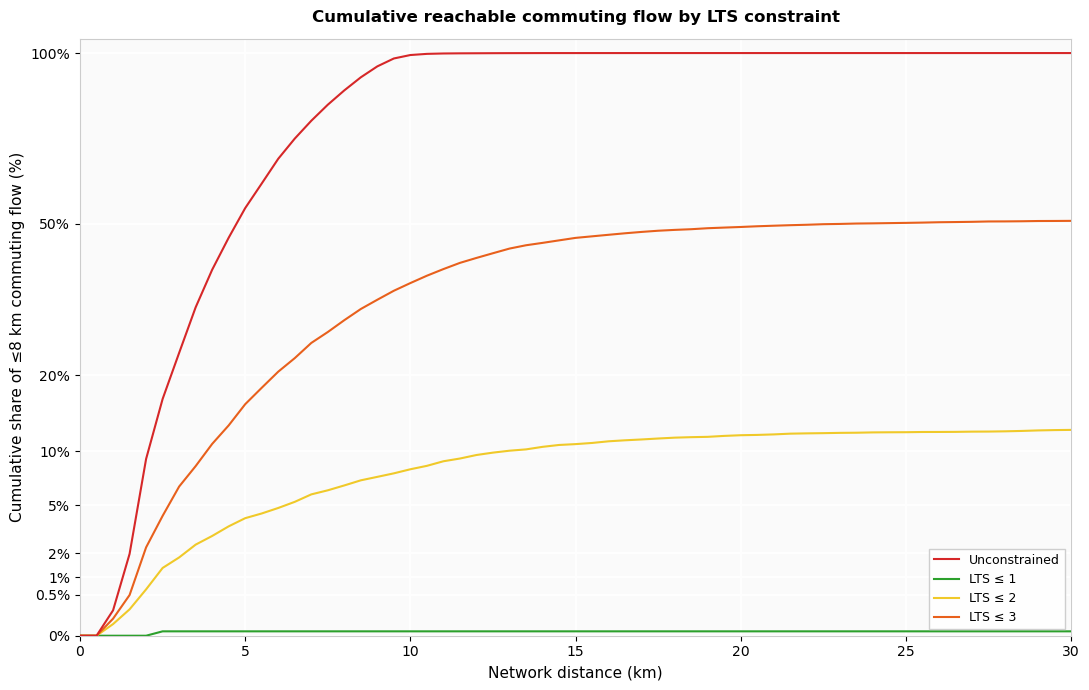

In [28]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#fafafa')
ax.grid(True, color='white', linewidth=1.2, zorder=0)
ax.set_axisbelow(True)

thresholds_m = np.arange(0, 30001, 500)

# Unconstrained baseline
valid_unc = commute_results["unconstrained"].dropna(subset=["distance_m"])
cum_base = [valid_unc[valid_unc["distance_m"] <= d]["flow"].sum() / total_8km_flow * 100
            for d in thresholds_m]
ax.plot(thresholds_m / 1000, cum_base,
        color=LTS_COLORS[4], linewidth=1.5, label="Unconstrained", zorder=4)

# Strict
for lts in [1, 2, 3]:
    strict = commute_results[(lts, "strict")]
    s_conn = strict.dropna(subset=["distance_m"])
    cum_pct = [s_conn[s_conn["distance_m"] <= d]["flow"].sum() / total_8km_flow * 100
               for d in thresholds_m]
    ax.plot(thresholds_m / 1000, cum_pct,
            color=LTS_COLORS[lts], linestyle='-', linewidth=1.5,
            label=f"LTS ≤ {lts}", zorder=3)

ax.set_yscale("function", functions=(lambda x: np.sqrt(x), lambda x: x**2))
ax.set_ylim(0, 105)
ax.set_xlim(0, 30)
ax.set_yticks([0, 0.5, 1, 2, 5, 10, 20, 50, 100])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:g}%"))
ax.set_xlabel("Network distance (km)", fontsize=11)
ax.set_ylabel("Cumulative share of ≤8 km commuting flow (%)", fontsize=11)
ax.set_title("Cumulative reachable commuting flow by LTS constraint",
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9, frameon=True,
          fancybox=False, edgecolor='#cccccc', framealpha=0.95)
for spine in ax.spines.values():
    spine.set_color('#cccccc')
plt.tight_layout()
plt.savefig(FIG_DIR / "commuting_flow_by_lts.png", dpi=300, bbox_inches="tight")
plt.show()


#### 7.3 Origin MSOA Connectivity Choropleth

For each origin MSOA, compute the flow-weighted share of commuting trips
(≤ 8 km straight-line) that remain connected under LTS ≤ 2 and LTS ≤ 3
constraints. This shows the spatial distribution of who is served by the
low-stress network.

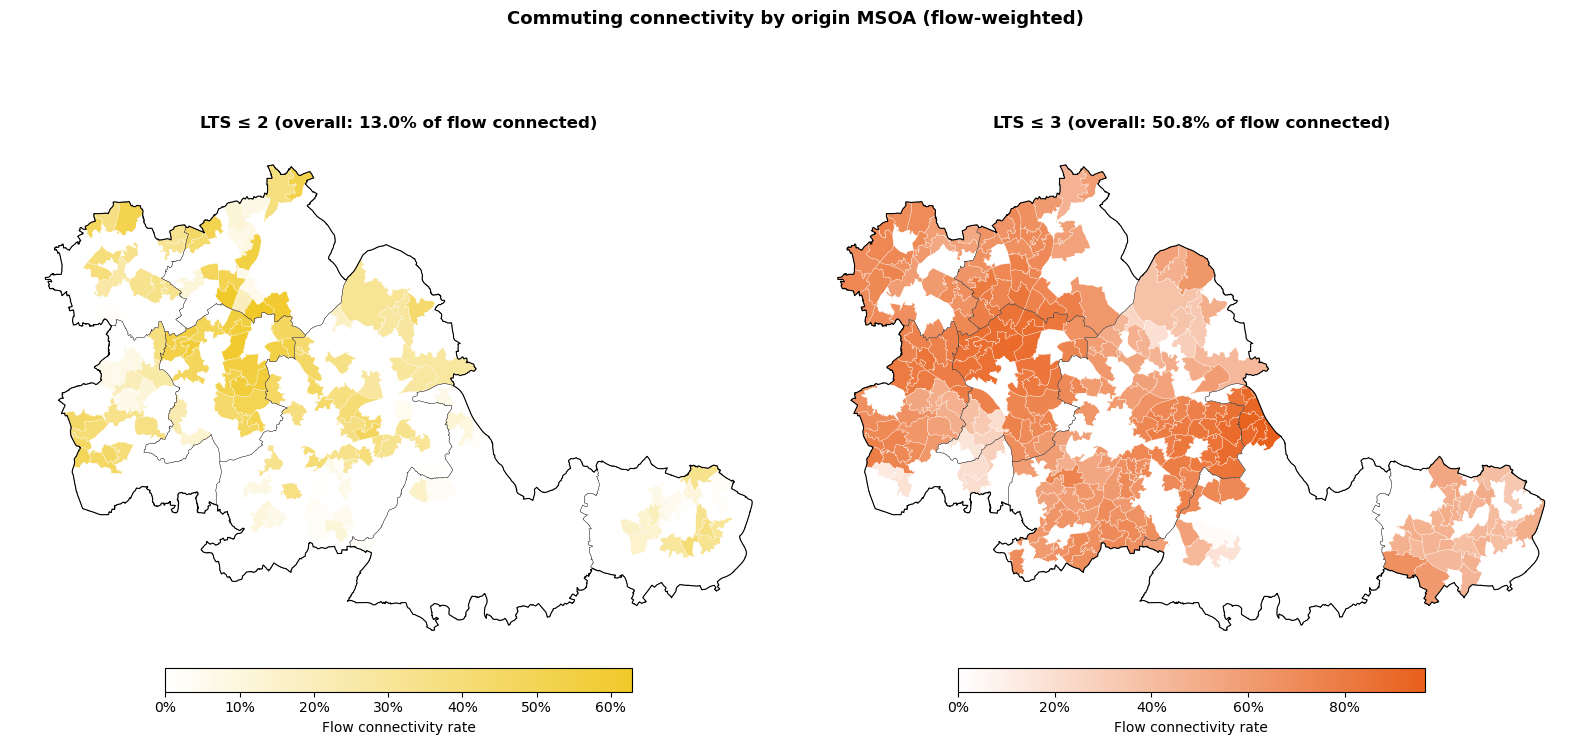

In [45]:
# Per-origin flow-weighted connectivity rate
def origin_connectivity(res_df):
    df = res_df.copy()
    df["connected"] = df["distance_m"].notna()
    agg = df.groupby("o_msoa").apply(
        lambda g: (g.loc[g["connected"], "flow"].sum() / g["flow"].sum())
        if g["flow"].sum() > 0 else np.nan
    ).rename("conn_rate").reset_index()
    return agg

conn_lts2 = origin_connectivity(commute_results[(2, "strict")])
conn_lts3 = origin_connectivity(commute_results[(3, "strict")])

# Merge onto MSOA polygons for plotting
msoa_plot = msoa_wm[[msoa_code_col, "geometry"]].copy()
msoa_plot = msoa_plot.merge(conn_lts2.rename(columns={"conn_rate": "lts2_rate"}),
                            left_on=msoa_code_col, right_on="o_msoa", how="left")
msoa_plot = msoa_plot.merge(conn_lts3.rename(columns={"conn_rate": "lts3_rate"}),
                            left_on=msoa_code_col, right_on="o_msoa", how="left",
                            suffixes=("", "_d"))
msoa_plot = msoa_plot.drop(columns=[c for c in msoa_plot.columns if c.endswith("_d") or c == "o_msoa"])

# Two-panel choropleth
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor("white")

panels = [
    (axes[0], "lts2_rate", "LTS ≤ 2", "#f0c929"),
    (axes[1], "lts3_rate", "LTS ≤ 3", "#e8601c"),
]

from matplotlib.colors import LinearSegmentedColormap

for ax, col, label, hi_color in panels:
    ax.set_facecolor("white")

    cmap = LinearSegmentedColormap.from_list(
        f"cmap_{col}", ["#ffffff", hi_color]
    )

    # Use actual data max as the upper bound
    vmax = msoa_plot[col].max()

    msoa_plot.dropna(subset=[col]).plot(
        column=col, ax=ax, cmap=cmap, vmin=0, vmax=vmax,
        edgecolor="white", linewidth=0.2,
        legend=True,
        legend_kwds={"label": "Flow connectivity rate",
                     "orientation": "horizontal", "shrink": 0.6, "pad": 0.02,
                     "format": lambda x, _: f"{x*100:.0f}%"},
    )

    # LAD internal boundaries
    study_area.boundary.plot(ax=ax, color="#080000", linewidth=0.2, zorder=3)
    # Study-area outer boundary
    study_area.dissolve().boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=4)

    # Overall flow-weighted connectivity for the title
    lts_num = 2 if "2" in label else 3
    res_agg = commute_results[(lts_num, "strict")]
    conn_flow = res_agg.dropna(subset=["distance_m"])["flow"].sum()
    overall = conn_flow / total_8km_flow * 100

    ax.set_title(f"{label} (overall: {overall:.1f}% of flow connected)",
                 fontsize=12, fontweight="bold", pad=10)
    ax.set_axis_off()

fig.suptitle("Commuting connectivity by origin MSOA (flow-weighted)",
             fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()
# plt.savefig(FIG_DIR / "commuting_connectivity_choropleth.png", dpi=300, bbox_inches="tight")
plt.show()

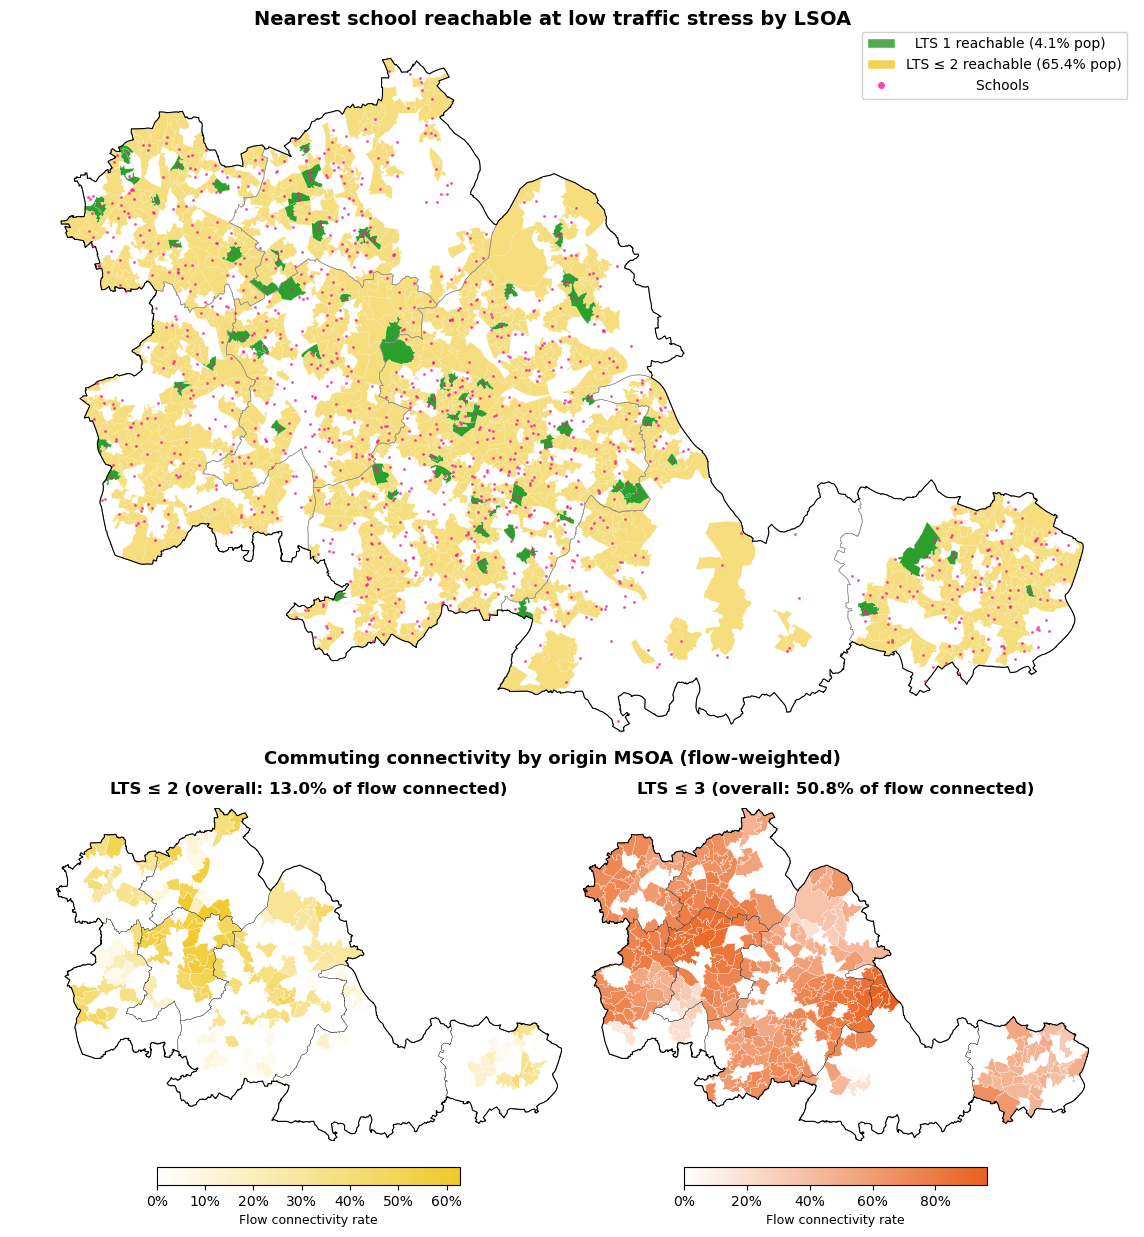

In [98]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

fig = plt.figure(figsize=(16, 14.5))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(2, 2, height_ratios=[2, 0.9], hspace=0.08, wspace=0.01)

# =================================================================
# TOP ROW: School accessibility (spans both columns)
# =================================================================
ax_school = fig.add_subplot(gs[0, :])

tier_colors = {"lts1": "#2ca02c", "lts2": "#f0c82998"}
for tier, color in tier_colors.items():
    subset = lsoa_wm[lsoa_wm["school_tier"] == tier]
    if len(subset):
        subset.plot(ax=ax_school, color=color, edgecolor="white", linewidth=0.1)

study_area.boundary.plot(ax=ax_school, color="#888888", linewidth=0.4, zorder=3)
study_area.dissolve().boundary.plot(ax=ax_school, color="black", linewidth=0.8, zorder=4)

schools_plot = schools_wm.to_crs(lsoa_wm.crs)
ax_school.scatter(
    schools_plot.geometry.x, schools_plot.geometry.y,
    s=4, color="#FF1493", alpha=0.8, marker="o",
    linewidths=0, zorder=5,
)

legend_elems = [
    Patch(facecolor="#2ca02cd5", edgecolor="white",
          label=f"  LTS 1 reachable ({pct_lts1:.1f}% pop)"),
    Patch(facecolor="#f0c829ca", edgecolor="white",
          label=f"LTS ≤ 2 reachable ({pct_lts2:.1f}% pop)"),
    Line2D([0], [0], marker="o", color="none", markeredgewidth=0,
           markerfacecolor="#FF1493", markersize=5, alpha=0.8, label="                Schools"),
]
ax_school.legend(handles=legend_elems, loc="upper right", fontsize=10,
                 frameon=True, framealpha=0.9)
ax_school.set_title("")  # clear the default
fig.text(0.5, 0.88, "Nearest school reachable at low traffic stress by LSOA",
         fontsize=14, fontweight="bold", ha="center")
ax_school.set_axis_off()

# =================================================================
# BOTTOM ROW: Commuting connectivity (one panel each)
# =================================================================
ax_lts2 = fig.add_subplot(gs[1, 0])
ax_lts3 = fig.add_subplot(gs[1, 1])

fig.text(0.5, 0.37, "Commuting connectivity by origin MSOA (flow-weighted)",
         fontsize=13, fontweight="bold", ha="center")

panels = [
    (ax_lts2, "lts2_rate", "LTS ≤ 2", "#f0c929", 2),
    (ax_lts3, "lts3_rate", "LTS ≤ 3", "#e8601c", 3),
]

for ax, col, label, hi_color, lts_num in panels:
    ax.set_facecolor("white")
    cmap = LinearSegmentedColormap.from_list(f"cmap_{col}", ["#ffffff", hi_color])
    vmax = msoa_plot[col].max()

    msoa_plot.dropna(subset=[col]).plot(
        column=col, ax=ax, cmap=cmap, vmin=0, vmax=vmax,
        edgecolor="white", linewidth=0.2,
        legend=False,
    )

    study_area.boundary.plot(ax=ax, color="#080000", linewidth=0.2, zorder=3)
    study_area.dissolve().boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=4)

    res_agg = commute_results[(lts_num, "strict")]
    conn_flow = res_agg.dropna(subset=["distance_m"])["flow"].sum()
    overall = conn_flow / total_8km_flow * 100

    ax.set_title(f"{label} (overall: {overall:.1f}% of flow connected)",
                 fontsize=12, fontweight="bold", pad=10)
    ax.set_axis_off()

# Sync extents after plotting so maps align and fill the space
bounds = study_area.dissolve().total_bounds
for ax in [ax_lts2, ax_lts3]:
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.margins(0)

# Shift bottom axes closer together
pad = 0.03

pos_l = ax_lts2.get_position()
pos_r = ax_lts3.get_position()
ax_lts2.set_position([pos_l.x0 + pad, pos_l.y0, pos_l.width, pos_l.height])
ax_lts3.set_position([pos_r.x0 - pad, pos_r.y0, pos_r.width, pos_r.height])

# Add colorbars manually, positioned relative to each shifted axes
for ax, col, hi_color in [
    (ax_lts2, "lts2_rate", "#f0c929"),
    (ax_lts3, "lts3_rate", "#e8601c"),
]:
    cmap = LinearSegmentedColormap.from_list(f"cbar_{col}", ["#ffffff", hi_color])
    vmax = msoa_plot[col].max()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
    sm._A = []

    pos = ax.get_position()
    cax = fig.add_axes([pos.x0 + pos.width * 0.2, pos.y0 - 0.03,
                        pos.width * 0.6, 0.012])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label("Flow connectivity rate", fontsize=9)
    cbar.ax.xaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")

plt.savefig(FIG_DIR / "od_connectivity_combined.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Export

In [28]:
# Save commuting results (strict only)
for key, res in commute_results.items():
    if isinstance(res, pd.DataFrame):
        label = str(key).replace(" ", "_").replace(",", "_").replace("(", "").replace(")", "").replace("'", "")
        res.to_csv(OUTPUT_DIR / f"commuting_od_{label}.csv", index=False)

# Save school accessibility as LSOA-level table (strict only)
school_summary = pd.DataFrame({"LSOA21CD": list(lsoa_to_node.keys())})
for lts in [1, 2, 3, 4]:
    school_summary[f"school_dist_lts{lts}"] = school_summary["LSOA21CD"].map(school_results[lts])
school_summary.to_csv(OUTPUT_DIR / "lsoa_school_accessibility.csv", index=False)

print("=" * 60)
print("EXPORT COMPLETE")
print("=" * 60)
print(f"Commuting OD results: {OUTPUT_DIR}/commuting_od_*.csv")
print(f"School accessibility:  {OUTPUT_DIR}/lsoa_school_accessibility.csv")


EXPORT COMPLETE
Commuting OD results: ../Data/Cleaned/commuting_od_*.csv
School accessibility:  ../Data/Cleaned/lsoa_school_accessibility.csv
